# Channel Validate 从零搭建教程

这份 notebook 是“纯源码入门版”。目标不是教你怎么用现成模板，而是直接从底层一步一步搭出：

- 一个 NEURON 单室模型
- 一个 braincell 单室模型
- 同一个 Kv 通道
- 同一个 step current 刺激
- 最后把两边电压画在一起做最小对比

如果你之后想切换到可复用模板和 sweep，请再看：

- `channel_validate.ipynb`


## 0. 准备

运行本 notebook 前，先确认：

- 当前目录里有 `mods/` 目录，示例机制文件是 `mods/kv.mod`
- 已经在 `mods/` 目录执行过 `nrnivmodl`
- notebook kernel 指向可用的 `braincell` 环境

下面先把当前工作目录视为 `mod_validate`，并导入后面会用到的包。


In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = (8, 4)

ROOT = Path.cwd().resolve()
MODS_DIR = ROOT / 'mods'
if not MODS_DIR.is_dir():
    raise FileNotFoundError('请从包含 mods/ 目录的 mod_validate 目录启动或运行本 notebook。')

ROOT


PosixPath('/home/swl/braincell/braincell/mech/mod_validate')

In [2]:
print('当前目录:', ROOT)
print('mods directory exists:', MODS_DIR.is_dir())
print('mods/kv.mod exists:', (MODS_DIR / 'kv.mod').exists())
print('如果还没编译 mod，请先在终端执行:')
print(f'cd {MODS_DIR} && nrnivmodl')


当前目录: /home/swl/braincell/braincell/mech/mod_validate
mods directory exists: True
mods/kv.mod exists: True
如果还没编译 mod，请先在终端执行:
cd /home/swl/braincell/braincell/mech/mod_validate/mods && nrnivmodl


## 1. 先把公共参数展开成最原始的变量

这里故意不用配置字典，尽量把变量直接摊开，方便你看清楚每个量最后是怎么进入 NEURON 和 braincell 的。


In [3]:
## sim parameters
dt_ms = 0.025
tstop_ms = 100.0
v_init_mV = -65.0
temperature_celsius = 25.0

## cell parameters
L_um = 10.0
diam_um = 100.0 / np.pi
radius_um = diam_um / 2.0
cm_uF_cm2 = 1.0

## names for this raw tutorial
mechanism_name = 'Kv'
neuron_current_name = 'ik'
neuron_current_sign = -1.0
gate_var_name = 'n'
braincell_ion_attr_name = 'k'
braincell_channel_attr_name = 'IK'

ek_mV = -80.0
leak_g_S_cm2 = 1e-4
leak_e_mV = -65.0

gbar_S_cm2 = 0.01
v12_mV = 25.0
q_mV = 9.0

## stim parameters
stim_delay_ms = 10.0
stim_dur_ms = 50.0
stim_amp_nA = 0.01


## 2. NEURON：一步一步搭一个单室通道模型

下面不调用 helper，直接使用 NEURON 原生对象：

- `Section`
- `pas`
- `mechanism_name` 对应的 mod 机制
- `IClamp`
- `Vector().record(...)`

注意这里不要在 notebook 里无条件重复 `load_mechanisms()`。
Jupyter kernel 会保留上一轮的 NEURON 状态，所以更稳的做法是：

- 先 probe 一次目标机制是否已经可用
- 只有不可用时才调用 `load_mechanisms()`

这个 notebook 仍然用 `Kv` / `k` / `IK` 做演示，但 NEURON 和 braincell 的观测名字已经提成变量，后面替换会更直接。


In [4]:
from neuron import h, load_mechanisms


def ensure_mechanism_available(mod_dir: Path, mechanism: str) -> None:
    probe = h.Section(name=f'{mechanism}_probe')
    try:
        probe.insert(mechanism)
        return
    except Exception:
        pass
    finally:
        h.delete_section(sec=probe)

    load_mechanisms(str(mod_dir))

    probe = h.Section(name=f'{mechanism}_probe')
    try:
        probe.insert(mechanism)
    except Exception as exc:
        raise RuntimeError(
            f"Mechanism '{mechanism}' is unavailable after load_mechanisms({mod_dir}). "
            f"Please run 'nrnivmodl' inside {mod_dir} first."
        ) from exc
    finally:
        h.delete_section(sec=probe)


h.load_file('stdrun.hoc')
ensure_mechanism_available(MODS_DIR, mechanism_name)

soma = h.Section(name='soma')
soma.L = L_um
soma.diam = diam_um
soma.nseg = 1
soma.cm = cm_uF_cm2

soma.insert('pas')
for seg in soma:
    seg.pas.g = leak_g_S_cm2
    seg.pas.e = leak_e_mV

soma.insert(mechanism_name)
for seg in soma:
    mech = getattr(seg, mechanism_name)
    mech.gbar = gbar_S_cm2
    mech.v12 = v12_mV
    mech.q = q_mV

soma.ek = ek_mV

stim = h.IClamp(soma(0.5))
stim.delay = stim_delay_ms
stim.dur = stim_dur_ms
stim.amp = stim_amp_nA

t_vec = h.Vector().record(h._ref_t)
v_vec = h.Vector().record(soma(0.5)._ref_v)
current_vec = h.Vector().record(getattr(soma(0.5), f'_ref_{neuron_current_name}'))
gate_vec = h.Vector().record(getattr(getattr(soma(0.5), mechanism_name), f'_ref_{gate_var_name}'))

h.cvode_active(0)
h.dt = dt_ms
h.celsius = temperature_celsius
h.finitialize(v_init_mV)
h.tstop = tstop_ms
h.run()

# Keep the raw recorded vectors first.
# NEURON usually has one extra initial sample when using Vector.record(...) + h.run().
t_neuron_ms = np.asarray(t_vec, dtype=float).reshape(-1)
v_neuron_mV = np.asarray(v_vec, dtype=float).reshape(-1)
ion_current_neuron_mA_cm2 = neuron_current_sign * np.asarray(current_vec, dtype=float).reshape(-1)
gate_neuron = np.asarray(gate_vec, dtype=float).reshape(-1)

t_neuron_ms[:5], v_neuron_mV[:5]


--No graphics will be displayed.


(array([0.   , 0.025, 0.05 , 0.075, 0.1  ]),
 array([-65.        , -65.00016982, -65.00033921, -65.00050817,
        -65.00067671]))

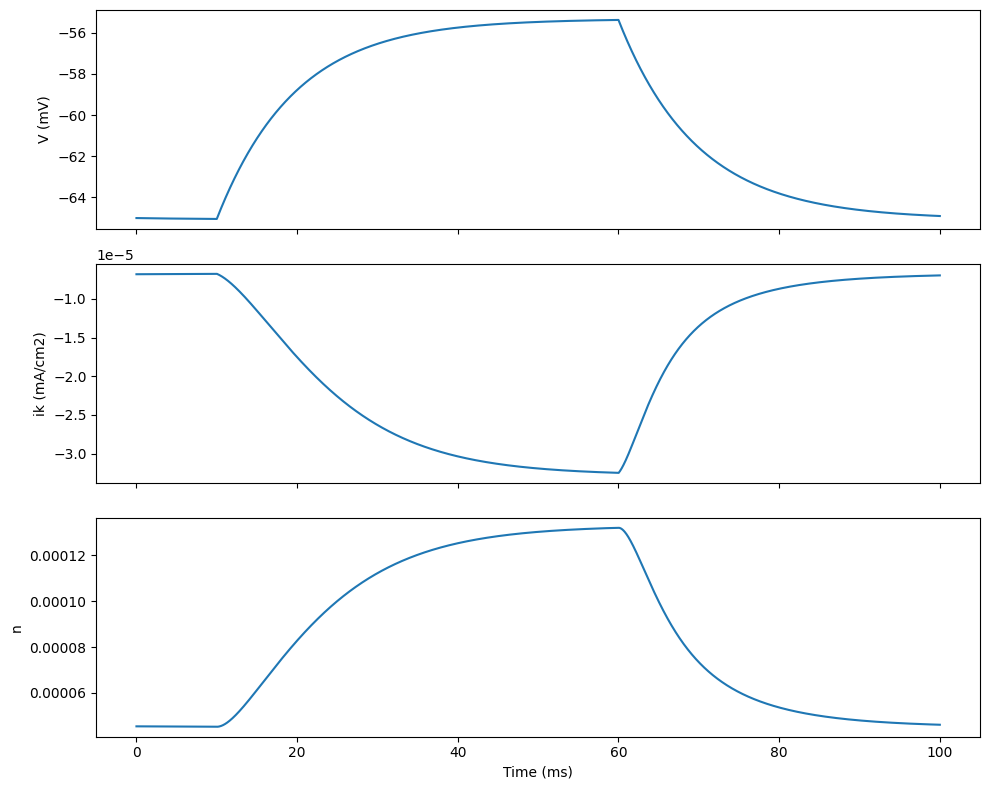

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(t_neuron_ms, v_neuron_mV)
axes[0].set_ylabel('V (mV)')

axes[1].plot(t_neuron_ms, ion_current_neuron_mA_cm2)
axes[1].set_ylabel(f'{neuron_current_name} (mA/cm2)')

axes[2].plot(t_neuron_ms, gate_neuron)
axes[2].set_ylabel(gate_var_name)
axes[2].set_xlabel('Time (ms)')

fig.tight_layout()
plt.show()


## 3. braincell：一步一步搭一个单室通道模型

这里同样不调用现成 helper，直接定义最小的 `SingleCompartment` 子类，然后手工把默认示例通道绑定进去。

- `PotassiumFixed`
- `IK_Kv_test`
- `IL`

虽然默认还是 Kv 示例，但后面的观测代码会通过属性名变量访问，替换时会更直接。


In [6]:
os.environ.setdefault('JAX_PLATFORMS', 'cpu')

import braincell
import brainstate
import braintools
import brainunit as u


class ScratchSingleChannelCell(braincell.SingleCompartment):
    def __init__(self, size: int = 1):
        super().__init__(
            size,
            length=L_um * u.um,
            radius=radius_um * u.um,
            C=cm_uF_cm2 * u.uF / (u.cm ** 2),
            solver='rk4',
            V_initializer=braintools.init.Uniform(v_init_mV * u.mV, v_init_mV * u.mV),
        )

        self.k = braincell.ion.PotassiumFixed(size, E=ek_mV * u.mV)
        self.k.add(
            IK=braincell.channel.IK_Kv_test(
                size,
                g_max=gbar_S_cm2 * (u.siemens / (u.cm ** 2)),
                v12=v12_mV * u.mV,
                q=q_mV * u.mV,
            )
        )
        self.IL = braincell.channel.IL(
            size,
            E=leak_e_mV * u.mV,
            g_max=leak_g_S_cm2 * (u.siemens / (u.cm ** 2)),
        )


cell = ScratchSingleChannelCell(1)
cell.init_state()
cell.reset_state()


/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.5.1 is installed, but it is not compatible with the installed jaxlib version 0.6.2, so it will not be used.
  warnings.warn(
/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/braintools/surrogate.py:72: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  z = jnp.asarray(x >= 0, dtype=x.dtype)


In [7]:
ion_obj = getattr(cell, braincell_ion_attr_name)
channel_obj = getattr(ion_obj, braincell_channel_attr_name)


def step_fun(t):
    t_ms = t / u.ms
    active = u.math.logical_and(t_ms >= stim_delay_ms, t_ms < (stim_delay_ms + stim_dur_ms))
    i_nA = u.math.where(active, stim_amp_nA, 0.0)
    with brainstate.environ.context(t=t):
        cell.update(i_nA * u.nA)
    v_now = cell.V.value
    ion_current_now = ion_obj.current(v_now)
    gate_now = getattr(channel_obj, gate_var_name).value
    return v_now, i_nA, ion_current_now, gate_now


with brainstate.environ.context(dt=dt_ms * u.ms):
    times = u.math.arange(0.0 * u.ms, tstop_ms * u.ms, brainstate.environ.get_dt())
    v_seq, i_seq, ion_current_seq, gate_seq = brainstate.transform.for_loop(step_fun, times)

t_braincell_ms = np.asarray(times / u.ms, dtype=float).reshape(-1)
v_braincell_mV = np.asarray(v_seq / u.mV, dtype=float).reshape(-1)
i_braincell_nA = np.asarray(i_seq, dtype=float).reshape(-1)
ion_current_braincell_mA_cm2 = np.asarray(ion_current_seq / (u.mA / (u.cm ** 2)), dtype=float).reshape(-1)
gate_braincell = np.asarray(gate_seq, dtype=float).reshape(-1)

t_braincell_ms[:5], v_braincell_mV[:5]


(array([0.   , 0.025, 0.05 , 0.075, 0.1  ]),
 array([-65.00016785, -65.00033569, -65.00050354, -65.00067139,
        -65.00083923]))

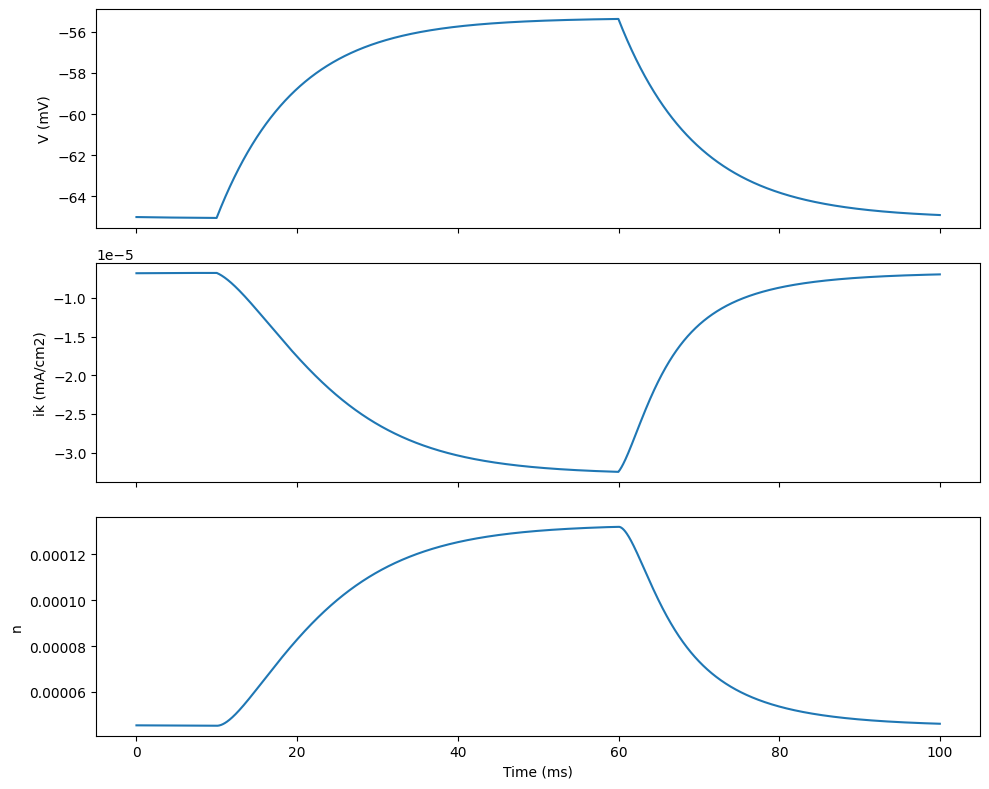

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(t_braincell_ms, v_braincell_mV)
axes[0].set_ylabel('V (mV)')

axes[1].plot(t_braincell_ms, ion_current_braincell_mA_cm2)
axes[1].set_ylabel(f'{neuron_current_name} (mA/cm2)')

axes[2].plot(t_braincell_ms, gate_braincell)
axes[2].set_ylabel(gate_var_name)
axes[2].set_xlabel('Time (ms)')

fig.tight_layout()
plt.show()


## 4. 把两边电压放在一起，做最小对比

这里只做最简单的对比：

- 先打印 NEURON 和 braincell 的数组长度
- 说明为什么 NEURON 往往会多一个初始采样点
- 在误差计算阶段再做截断和对齐
- 计算一个最基础的 MAE / RMSE

不引入额外 helper，方便你直接看到对比逻辑。


In [9]:
print('raw sizes before alignment:')
print(f'  NEURON t/v = {len(t_neuron_ms)} / {len(v_neuron_mV)}')
print(f'  braincell t/v = {len(t_braincell_ms)} / {len(v_braincell_mV)}')
print('NEURON uses Vector.record(...) + h.run(), so it keeps the initial state sample before the first integration step.')
print('For a fair error calculation, we drop that first NEURON sample here and then align both traces by the common length.')

t_neuron_aligned_ms = t_neuron_ms[1:]
v_neuron_for_error_mV = v_neuron_mV[1:]

n = min(len(t_neuron_aligned_ms), len(t_braincell_ms), len(v_neuron_for_error_mV), len(v_braincell_mV))
t_ms = t_neuron_aligned_ms[:n]
v_neuron_aligned = v_neuron_for_error_mV[:n]
v_braincell_aligned = v_braincell_mV[:n]

print('aligned sizes for error:')
print(f'  NEURON aligned = {len(v_neuron_aligned)}')
print(f'  braincell aligned = {len(v_braincell_aligned)}')

err = v_neuron_aligned - v_braincell_aligned
metrics = {
    'n_samples': int(n),
    'mae_mV': float(np.mean(np.abs(err))),
    'rmse_mV': float(np.sqrt(np.mean(err ** 2))),
    'max_abs_mV': float(np.max(np.abs(err))),
}

metrics


raw sizes before alignment:
  NEURON t/v = 4001 / 4001
  braincell t/v = 4000 / 4000
NEURON uses Vector.record(...) + h.run(), so it keeps the initial state sample before the first integration step.
For a fair error calculation, we drop that first NEURON sample here and then align both traces by the common length.
aligned sizes for error:
  NEURON aligned = 4000
  braincell aligned = 4000


{'n_samples': 4000,
 'mae_mV': 0.0022131934215321144,
 'rmse_mV': 0.0026644190249205456,
 'max_abs_mV': 0.004550098293577776}

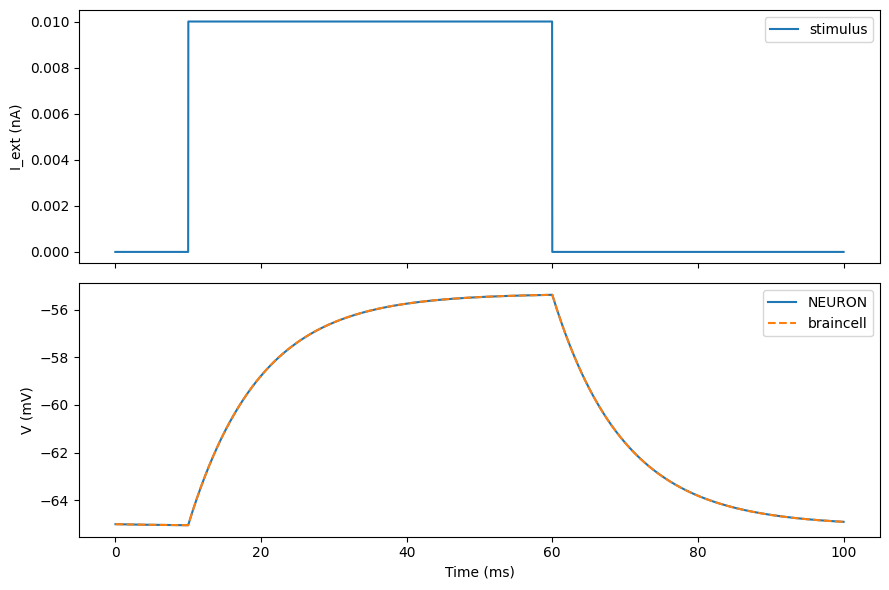

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axes[0].plot(t_neuron_ms, np.where((t_neuron_ms >= stim_delay_ms) & (t_neuron_ms < stim_delay_ms + stim_dur_ms), stim_amp_nA, 0.0), label='stimulus')
axes[0].set_ylabel('I_ext (nA)')
axes[0].legend()

axes[1].plot(t_ms, v_neuron_aligned, label='NEURON')
axes[1].plot(t_ms, v_braincell_aligned, '--', label='braincell')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('V (mV)')
axes[1].legend()

fig.tight_layout()
plt.show()


## 5. 下一步看什么

到这里你已经看到了“模型是怎么从零搭起来的”。

如果你下一步想要：

- 用更稳定的接口复现单个 case
- 少手写一些底层细节
- 系统 sweep 多个刺激条件

就切换到：

- `channel_validate.ipynb`

那一份 notebook 负责模板和 sweep 的使用，不再强调底层拼装过程。
